In [203]:
import scipy.stats as stats
import scipy.signal as signal
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
from matplotlib.ticker import FuncFormatter
from IPython.display import Math, display

import pandas as pd

In [2]:
plt.style.use('ggplot')
plt.rcParams['legend.labelcolor'] = 'black'

# Statistical and Physical Simulation

In this section, we will combine statistical simulation and physical simulation to create realistic time series data. We are using the data from the Kelmarsh wind farm in the UK. The data is from the year 2016 and is sampled at 10 minute intervals, [https://zenodo.org/records/5841834#.YgpBQ_so-V7](https://zenodo.org/records/5841834#.YgpBQ_so-V7). We have selected one of the turbines (Kelmarsh 3) and included wind speed, turbine power, current flow in each of the three phases, and the available capacity for production. The last series we can use for maintenance simulation. In addition, we want to extend to have multiple turbines in which all the wind speeds are correlated between 0.91-0.95. The goal is to simulate these random variables such that they have the same distribution and correlation structure as the historical data.


In [3]:
df = pd.read_parquet("kelmarsh_3_2016_01_01_to_2016_07_01.parquet")

## Descriptive Statistics

In [4]:
df.describe()

,Wind speed (m/s),Available Capacity for Production (kW),Power (kW),Current L2 / V (A),Current L1 / U (A),Current L3 / W (A)
count,21488.000000,22351.000000,21751.000000,21751.000000,21751.000000,21751.000000
mean,6.179809,1874.660537,509.609249,465.215333,461.801491,465.074104
std,2.849624,570.421754,548.011464,459.074262,458.874013,458.217609
min,0.000000,0.000000,-15.410000,0.000000,0.000000,0.000000
25%,4.218285,2050.000000,68.008274,113.569626,109.723373,114.621376
50%,5.821010,2050.000000,309.040009,297.720001,292.920013,296.401489
75%,7.710000,2050.000000,768.760010,685.535004,683.709747,686.940002
max,21.559999,2050.000000,2058.139893,1795.250000,1789.890015,1793.229980


In [5]:
df.corr()

,Wind speed (m/s),Available Capacity for Production (kW),Power (kW),Current L2 / V (A),Current L1 / U (A),Current L3 / W (A)
Wind speed (m/s),1.000000,-0.235018,0.774559,0.764835,0.765105,0.764770
Available Capacity for Production (kW),-0.235018,1.000000,0.234372,0.248210,0.247665,0.248028
Power (kW),0.774559,0.234372,1.000000,0.997540,0.997629,0.997568
Current L2 / V (A),0.764835,0.248210,0.997540,1.000000,0.999989,0.999990
Current L1 / U (A),0.765105,0.247665,0.997629,0.999989,1.000000,0.999989
Current L3 / W (A),0.764770,0.248028,0.997568,0.999990,0.999989,1.000000


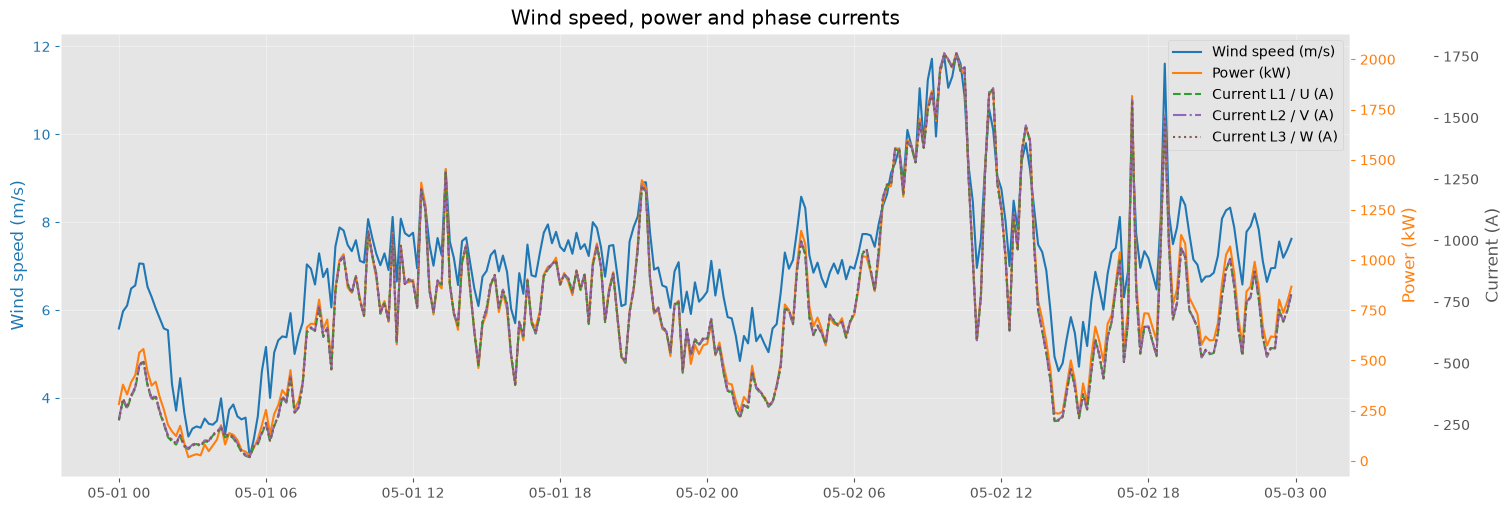

In [6]:
plot_df = df.loc["2016-05-01":"2016-05-02", :]

fig, ax_ws = plt.subplots(figsize=(15, 5), constrained_layout=True)

ax_pw = ax_ws.twinx()
ax_cur = ax_ws.twinx()

# Offset the third y-axis outward so it does not overlap with the second
ax_cur.spines['right'].set_position(('outward', 60))

# Distinct colors and line styles for each series
ws_color = 'tab:blue'
pw_color = 'tab:orange'
current_styles = [
    ('Current L1 / U (A)', 'tab:green',  '--'),
    ('Current L2 / V (A)', 'tab:purple', '-.'),
    ('Current L3 / W (A)', 'tab:brown',  ':'),
]

l_ws, = ax_ws.plot(plot_df.index, plot_df['Wind speed (m/s)'], color=ws_color, linestyle='-', label='Wind speed (m/s)')
l_pw, = ax_pw.plot(plot_df.index, plot_df['Power (kW)'], color=pw_color, linestyle='-', label='Power (kW)')
current_lines = [
    ax_cur.plot(plot_df.index, plot_df[c], color=color, linestyle=ls, label=c)[0]
    for c, color, ls in current_styles
]

ax_ws.set_ylabel('Wind speed (m/s)', color=ws_color)
ax_pw.set_ylabel('Power (kW)', color=pw_color)
ax_cur.set_ylabel('Current (A)')

ax_ws.tick_params(axis='y', colors=ws_color)
ax_pw.tick_params(axis='y', colors=pw_color)

# Keep grid only on the primary axis to reduce clutter
ax_pw.grid(False)
ax_cur.grid(False)

lines = [l_ws, l_pw, *current_lines]
ax_ws.legend(lines, [l.get_label() for l in lines], loc='upper right')
ax_ws.set_title('Wind speed, power and phase currents', color='black');

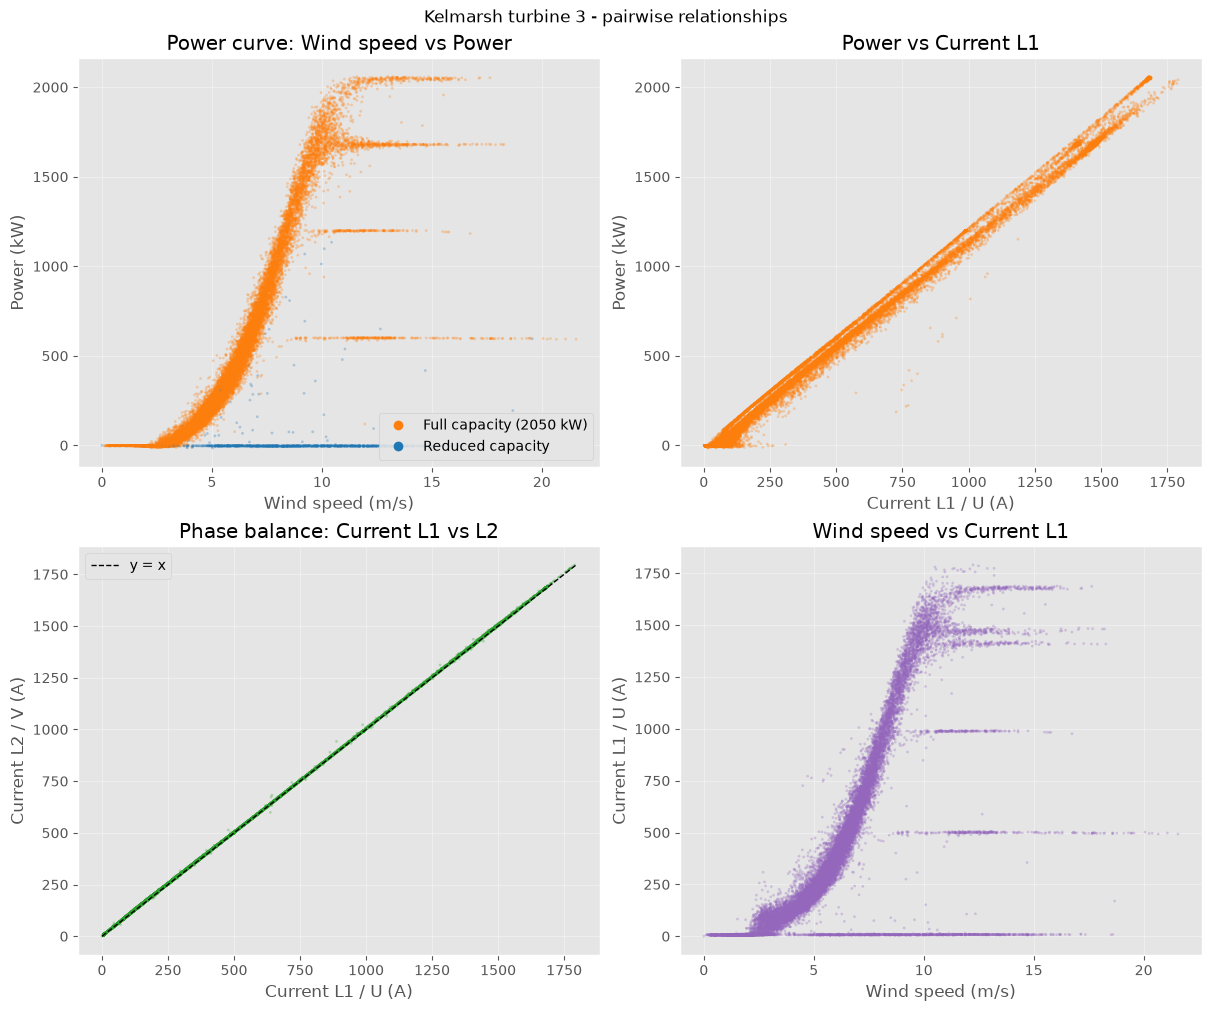

In [7]:
full_capacity = df["Available Capacity for Production (kW)"] == 2050.0

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10), constrained_layout=True)

scatter_kwargs = dict(s=4, alpha=0.3, edgecolors='none')

# Map boolean -> color
colors = np.where(full_capacity, 'tab:orange', 'tab:blue')

sc = axes[0, 0].scatter(
    df['Wind speed (m/s)'],
    df['Power (kW)'],
    c=colors,
    **scatter_kwargs,
)
axes[0, 0].set_xlabel('Wind speed (m/s)')
axes[0, 0].set_ylabel('Power (kW)')
axes[0, 0].set_title('Power curve: Wind speed vs Power', color='black')

# Legend (proxy handles, since we used raw colors)
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', color='tab:orange', label='Full capacity (2050 kW)'),
    Line2D([0], [0], marker='o', linestyle='', color='tab:blue',   label='Reduced capacity'),
]
axes[0, 0].legend(handles=legend_handles, loc='lower right', framealpha=0.9)

# 2. Power vs Current L1: near-linear at fixed voltage
axes[0, 1].scatter(df['Current L1 / U (A)'], df['Power (kW)'], color='tab:orange', **scatter_kwargs)
axes[0, 1].set_xlabel('Current L1 / U (A)')
axes[0, 1].set_ylabel('Power (kW)')
axes[0, 1].set_title('Power vs Current L1', color='black')

# 3. Phase balance: L1 vs L2 (should sit on the diagonal if phases are balanced)
axes[1, 0].scatter(df['Current L1 / U (A)'], df['Current L2 / V (A)'], color='tab:green', **scatter_kwargs)
lim = [
    min(df['Current L1 / U (A)'].min(), df['Current L2 / V (A)'].min()),
    max(df['Current L1 / U (A)'].max(), df['Current L2 / V (A)'].max()),
]
axes[1, 0].plot(lim, lim, color='black', linestyle='--', linewidth=1, label='y = x')
axes[1, 0].set_xlabel('Current L1 / U (A)')
axes[1, 0].set_ylabel('Current L2 / V (A)')
axes[1, 0].set_title('Phase balance: Current L1 vs L2', color='black')
axes[1, 0].legend()

# 4. Wind speed vs Current L1: same S-shape as the power curve
axes[1, 1].scatter(df['Wind speed (m/s)'], df['Current L1 / U (A)'], color='tab:purple', **scatter_kwargs)
axes[1, 1].set_xlabel('Wind speed (m/s)')
axes[1, 1].set_ylabel('Current L1 / U (A)')
axes[1, 1].set_title('Wind speed vs Current L1', color='black')

fig.suptitle('Kelmarsh turbine 3 - pairwise relationships', color='black');

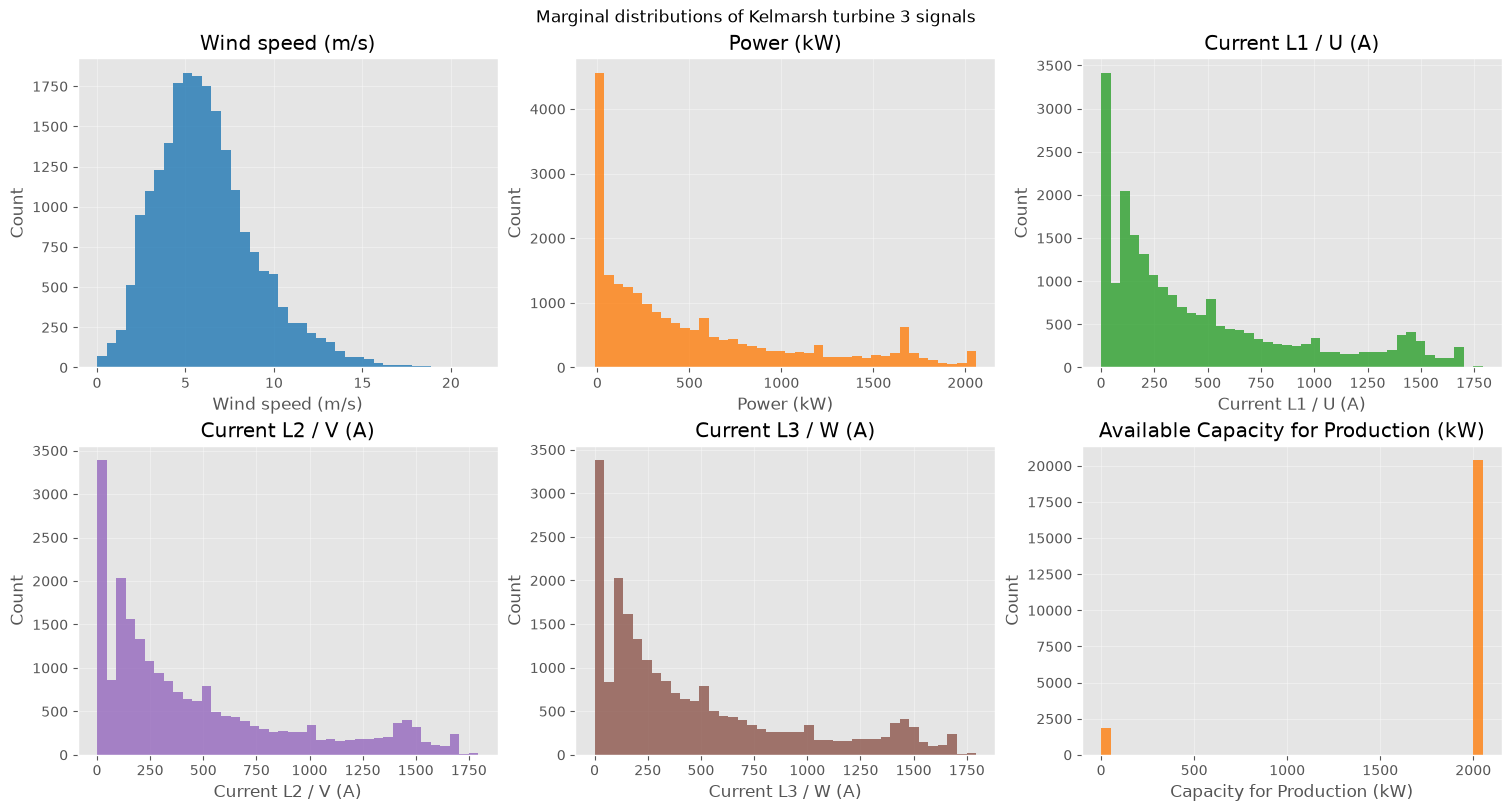

In [8]:
cols = [
    'Wind speed (m/s)',
    'Power (kW)',
    'Current L1 / U (A)',
    'Current L2 / V (A)',
    'Current L3 / W (A)',
]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple', 'tab:brown']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8), constrained_layout=True)
axes = axes.flatten()

bins = 40
for ax, col, color in zip(axes, cols, colors):
    data = df[col].dropna().values
    ax.hist(data, bins=bins, color=color, alpha=0.8)
    ax.set_title(col, color='black')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

# Overlay the three phase currents on the last (6th) subplot for direct comparison
ax = axes[-1]
ax.hist(df["Available Capacity for Production (kW)"].values, bins=bins, color='tab:orange', alpha=0.8)
ax.set_title("Available Capacity for Production (kW)", color="black")
ax.set_xlabel('Capacity for Production (kW)')
ax.set_ylabel('Count')

fig.suptitle('Marginal distributions of Kelmarsh turbine 3 signals', color='black');

Observations from the descriptive statistics and visualizations:

- The wind speed data follows a weibull distribution.
- The power output follows a power curve, with what seems to some curtailment at 1700, 1200, and 600 kW. Likely due to the wind turbine operator curtailing the power output to adjust for grid conditions.
- The three-phase currents are highly correlated with each other, as expected for a balanced three-phase system. The phase currents are also correlated with the power output, as expected since power is a function of current and voltage.

## Strategy for Simulating data.

We will reuse the results from the [](#statistics:simulation) to simulate the wind speed. Then, we will infer the power curve from the historical data, such that power can be calclulated from the simlated wind speed data. Finally, we will assume voltage is close to constant, such that the current can be calculated from the power using the formula $I = P/(Vcos(\phi))$, where $V$ is the voltage and $\phi$ is the phase angle. We will assume that $Vcos(\phi)$ is constant, such that we can calculate the current from the power using a simple linear relationship.

In addition, we will account for maintenance. To do this, we will use the "Available Capacity for Production" time series to creat the events from historical data and fit this to a distribution. Then, power is given by the power curve and not maintenance. Finally, we will simulate a net cash flow as $revenue (price*power*timedelta) - opex - maintenance cost$. We will assume fixed price, opex and maintenance cost.

Finally, we will extend the approach to multilpe turbines by using a VAR(1) process to simulate correlated wind speeds as in [](#statistics:simulation).

## Inferring Power Curve

We want to infer a power curve that we can use to simulate power based on the wind speed. The plan is to slice wind speed into bins of 0.5 m/s width, Then, for each bin assume a normal distribution and calculate the mean and standard deviation of power given that bin. To deal with the outliers caused by the curtailment, we will find an upper and lower bound for each bin. Then, filter the power data with these bounds to calculate the mean and standard deviation.

To obtain the upper and lower bound, we notice that curtailment will only produce lower value outliers. Thus, we select the upper bound to be the 97%, and the lower bound to the the upper bound shifted by 1 m/s.

In [9]:
bins = np.arange(0, df["Wind speed (m/s)"].max(), 0.5)
df["wind_speed_bins"] = pd.cut(df["Wind speed (m/s)"], bins)

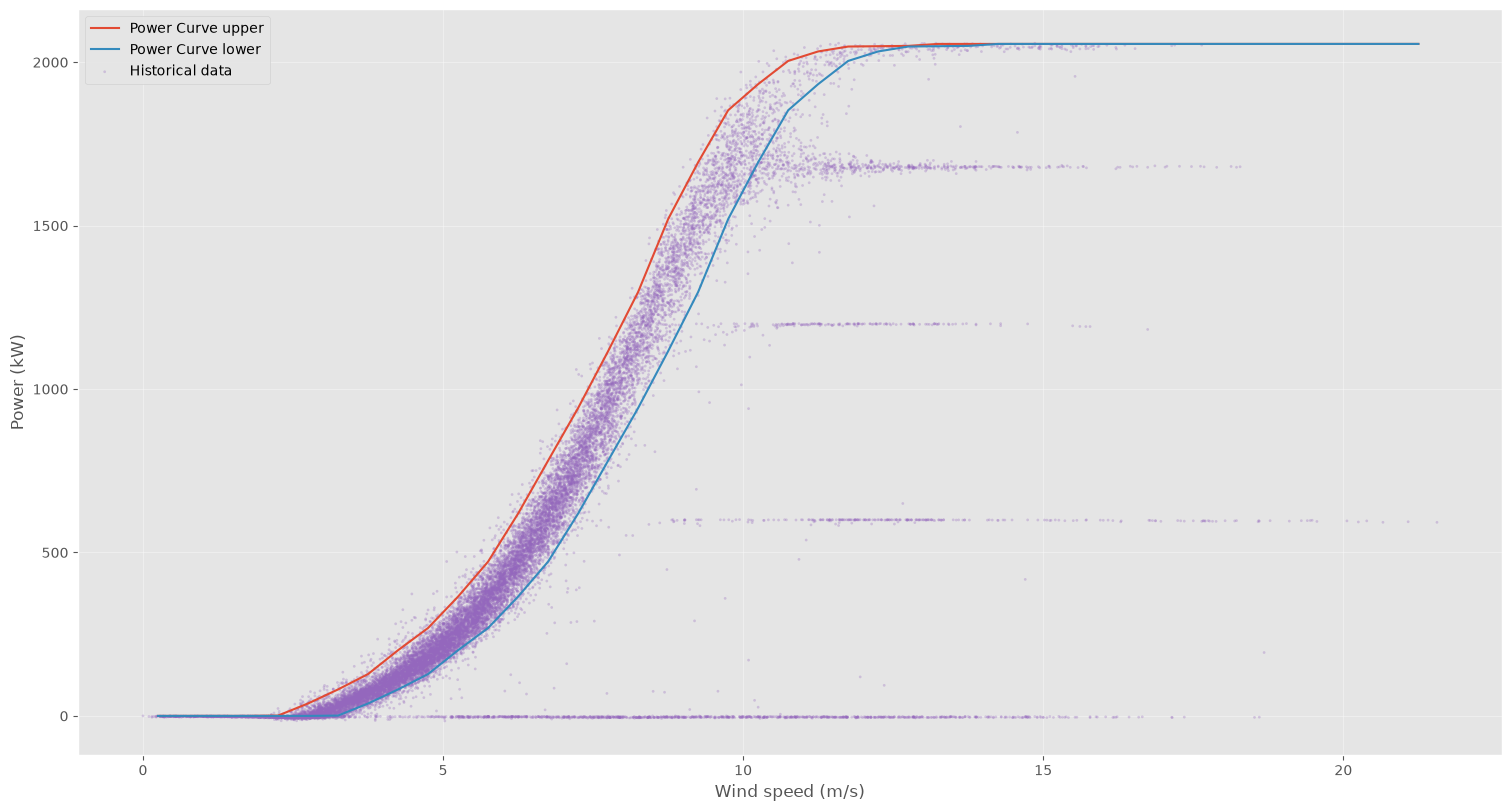

In [10]:
max_power: float = round(df['Power (kW)'].max(), ndigits=0)
power_curve_upper = []
wind_speeds = []
current_max = 0.0
for bin_, bin_df in sorted(df.groupby(by="wind_speed_bins"), key=lambda x: x[0].left):
    power_series = bin_df.loc[bin_df["Available Capacity for Production (kW)"] == 2050.0, "Power (kW)"]
    candidate = power_series.quantile(0.97)
    if pd.isna(candidate):
        selected_value = current_max
    else:
        selected_value = max(min(candidate, max_power), current_max)
    power_curve_upper.append(round(selected_value, ndigits=0))
    # Ensure monotonic increasing
    current_max = selected_value
    wind_speeds.append((bin_.left+bin_.right)/2)

fig, ax = plt.subplots(figsize=(15, 8), constrained_layout=True)
power_curve_upper = np.asarray(power_curve_upper)
power_curve_lower = np.zeros(shape=len(power_curve_upper))
# Shifting by 2 steps = 0.5*2 = 1.0 m/s
power_curve_lower[2:] = power_curve_upper[:-2]
wind_speeds = np.asarray(wind_speeds)
ax.plot(wind_speeds, power_curve_upper, label='Power Curve upper')
ax.plot(wind_speeds, power_curve_lower, label="Power Curve lower")

ax.scatter(df["Wind speed (m/s)"], df["Power (kW)"], color='tab:purple', **scatter_kwargs, label="Historical data")
ax.set_xlabel('Wind speed (m/s)')
ax.set_ylabel("Power (kW)")
ax.legend();

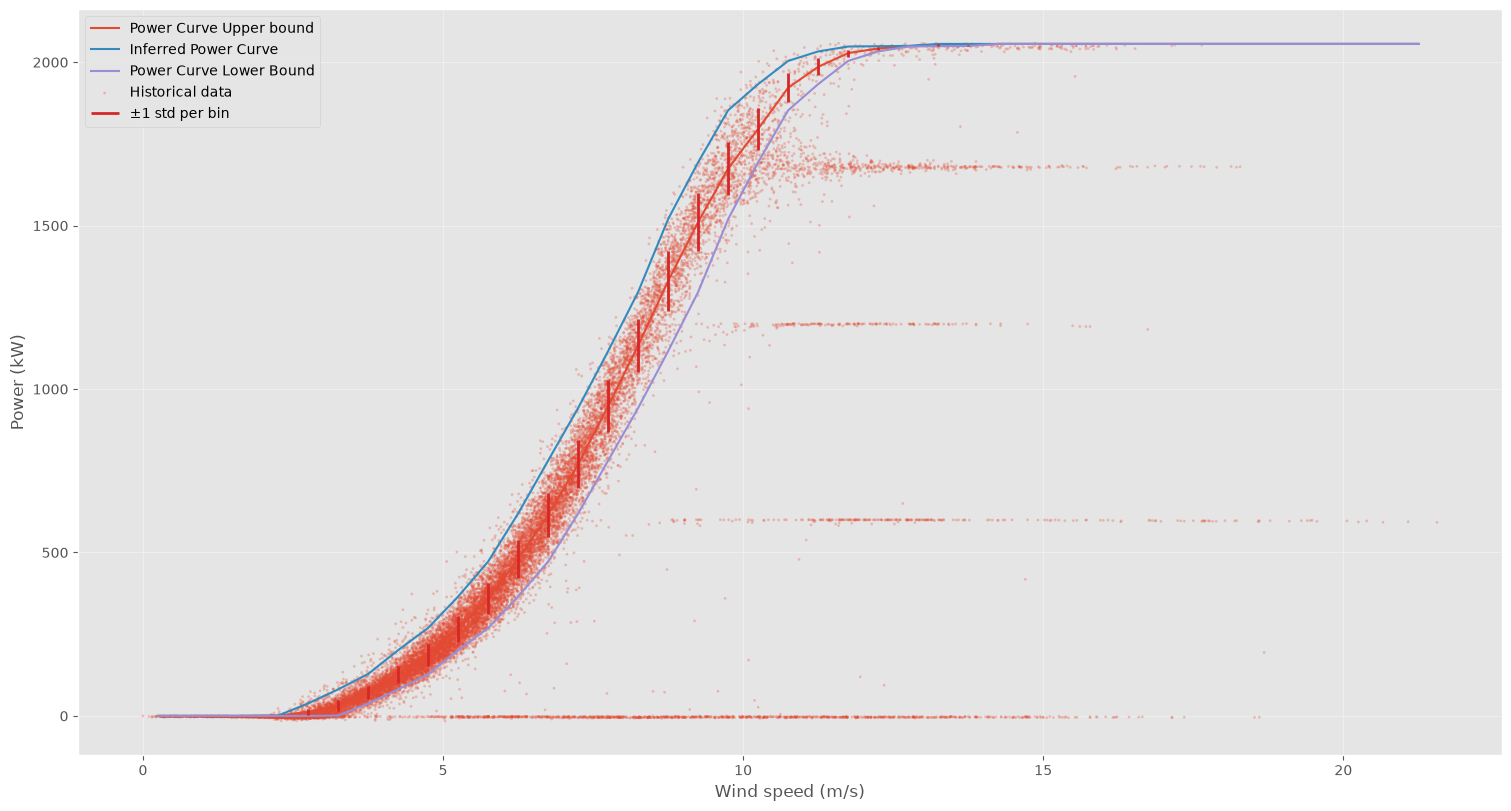

In [11]:
power_curve = []
power_curve_std = []
for (bin_, bin_df), low, high in zip(sorted(df.groupby(by="wind_speed_bins"), key=lambda x: x[0].left), power_curve_lower, power_curve_upper):
    power_series = bin_df["Power (kW)"]
    filtered_df = power_series[(power_series > low) & (power_series < high)]
    if filtered_df.empty:
        power_curve.append(low)
        power_curve_std.append(0)
    else:
        power_curve.append(round(filtered_df.mean(), ndigits=0))
        power_curve_std.append(round(filtered_df.std(), ndigits=2))
power_curve = np.asarray(power_curve)
power_curve_std = np.asarray(power_curve_std)
fix, ax = plt.subplots(figsize=(15, 8), constrained_layout=True)
ax.plot(wind_speeds, power_curve, label='Power Curve Upper bound')
ax.plot(wind_speeds, power_curve_upper, label='Inferred Power Curve')
ax.plot(wind_speeds, power_curve_lower, label='Power Curve Lower Bound')
ax.scatter(df["Wind speed (m/s)"], df["Power (kW)"], **scatter_kwargs, label="Historical data")
ax.vlines(
    wind_speeds,
    power_curve - power_curve_std,
    power_curve + power_curve_std,
    color='tab:red',
    linewidth=2,
    label='±1 std per bin',
)
ax.set_xlabel('Wind speed (m/s)')
ax.set_ylabel("Power (kW)")
ax.legend();

We can now use the new power curve to simulate the power given the wind speed. We will use a day of wind speed data for this simulation.

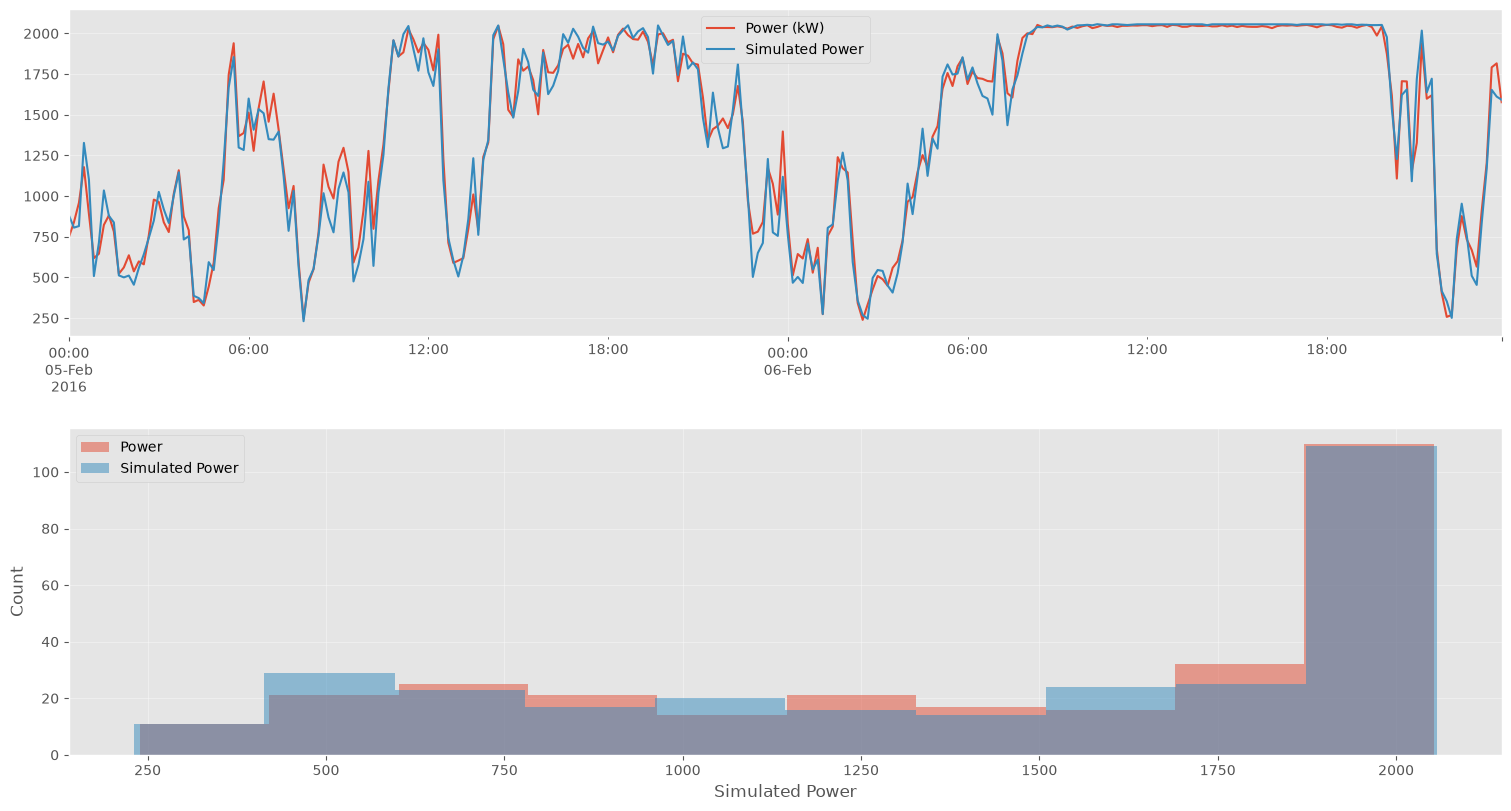

In [12]:
random_date = slice("2016-02-05","2016-02-06")
wind_speeds = df.loc[random_date, "Wind speed (m/s)"]
simulated_power = []
for wind_speed in wind_speeds:
    index = int(wind_speed // 0.5)
    simulated_value = np.random.normal(loc=power_curve[index], scale=power_curve_std[index])
    simulated_power.append(simulated_value)

fid, axes = plt.subplots(nrows=2, figsize=(15, 8), constrained_layout=True)
df.loc[random_date, "Power (kW)"].plot(ax=axes[0])
sim_series = pd.Series(index=wind_speeds.index, data=simulated_power)
sim_series.plot(ax=axes[0], label="Simulated Power")
axes[0].legend()
df.loc[random_date, "Power (kW)"].hist(ax=axes[1], alpha=0.5, label="Power")
sim_series.hist(ax=axes[1], alpha=0.5, label="Simulated Power")
axes[1].set_xlabel("Simulated Power")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Simulated Power")
axes[1].legend();

## Simulating Current

The current is expected to follow the formula $P=IVcos(\phi)$, and we expect the voltage to stay constant as well as the phase between current and voltage. Note that this will not hold all the time, for example, in start-up/shutdown, curtailment, or variation in the grid the voltage, or the phase, or both can change.

To account for the deviation, we do a simple linerage regression

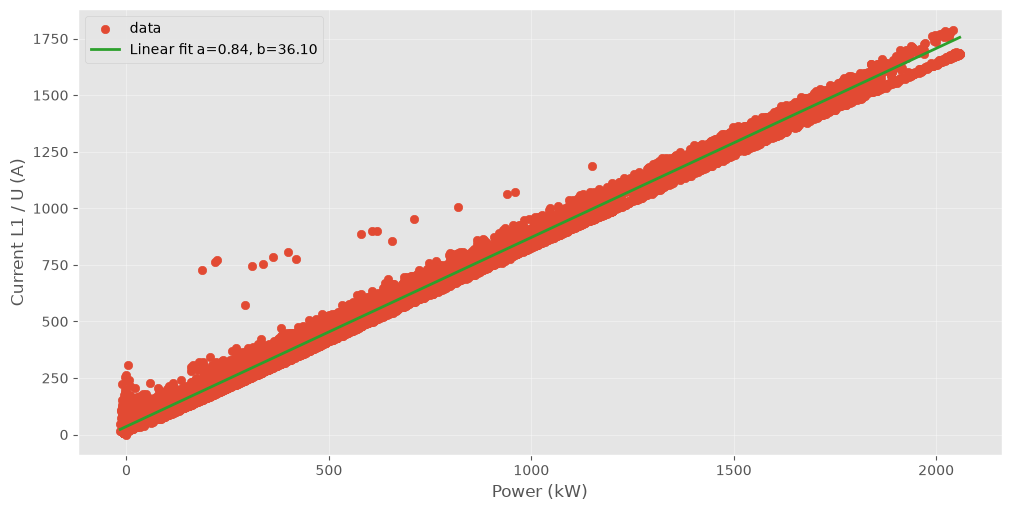

In [62]:
data = df[["Power (kW)", "Current L1 / U (A)"]].dropna()
a, b = np.polyfit(data["Power (kW)"].values, data["Current L1 / U (A)"].values, deg=1)

pred = np.polyval([a, b], data["Power (kW)"].values)
residuals = data["Current L1 / U (A)"] - pred
# Biased estimate of std (large sample so biased and unbiased
sigma = residuals.std()

fix, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.scatter(df["Power (kW)"], df["Current L1 / U (A)"], label="data")
x = np.linspace(df["Power (kW)"].min(), df["Power (kW)"].max(), 100)
ax.plot(x, a*x+b, color='tab:green', linewidth=2, label=f"Linear fit a={a:.2f}, b={b:.2f}")
ax.set_xlabel("Power (kW)")
ax.set_ylabel("Current L1 / U (A)")
ax.legend();

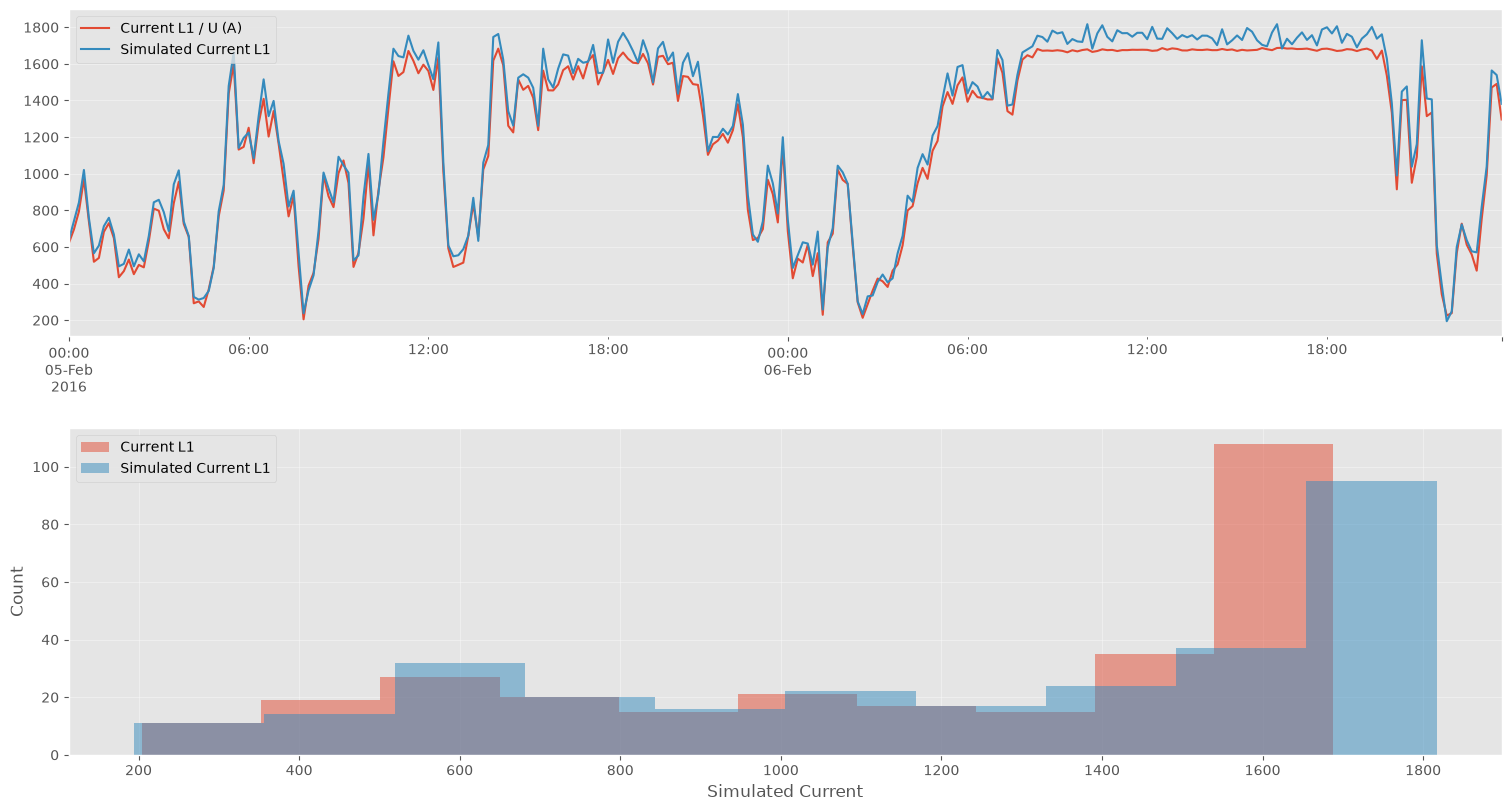

In [60]:
random_date = slice("2016-02-05", "2016-02-06")

simulated_current_l1 = np.polyval([a, b], df.loc[random_date, "Power (kW)"].values) + np.random.normal(loc=0, scale=sigma, size=len(df.loc[random_date, "Power (kW)"].values))

fid, axes = plt.subplots(nrows=2, figsize=(15, 8), constrained_layout=True)

df.loc[random_date, "Current L1 / U (A)"].plot(ax=axes[0])
sim_series = pd.Series(index=df.loc[random_date, "Current L1 / U (A)"].index, data=simulated_current_l1)
sim_series.plot(ax=axes[0], label="Simulated Current L1")
axes[0].legend()


df.loc[random_date, "Current L1 / U (A)"].hist(ax=axes[1], alpha=0.5, label="Current L1")
sim_series.hist(ax=axes[1], alpha=0.5, label="Simulated Current L1")
axes[1].set_xlabel("Simulated Current")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Simulated Current")
axes[1].legend();

## Simulating currents

The three current has a phase shift between them. We will simply to a lineare regression to simulate these as well.

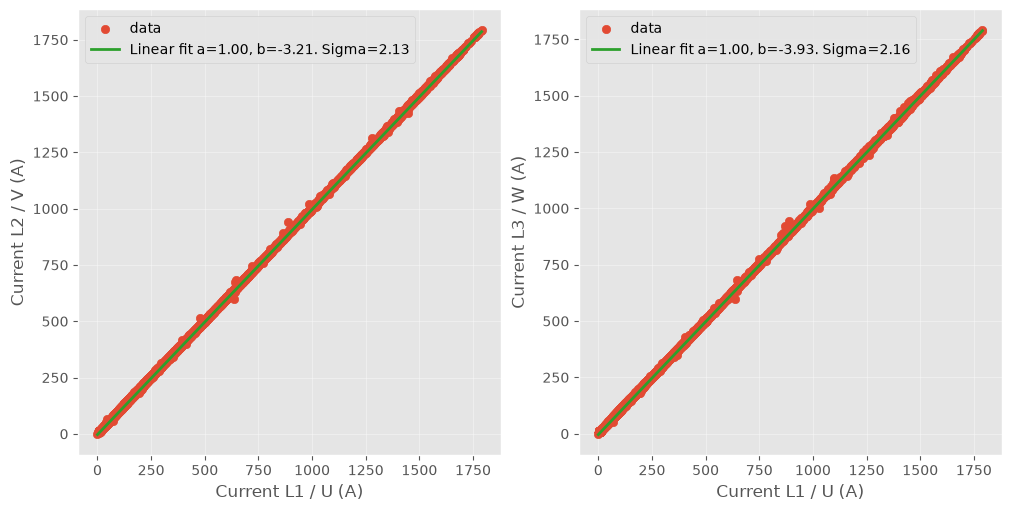

In [74]:
x_col = "Current L1 / U (A)"
fix, axes = plt.subplots(ncols=2, figsize=(10, 5), constrained_layout=True)
for  no, y_col in enumerate(["Current L2 / V (A)", "Current L3 / W (A)"]):
    data = df[[x_col, y_col]].dropna()
    a, b = np.polyfit(data[y_col].values, data[x_col].values, deg=1)

    pred = np.polyval([a, b], data[y_col].values)
    residuals = data[x_col] - pred
    # Biased estimate of std (large sample so biased and unbiased
    sigma = residuals.std()

    ax = axes[no]
    ax.scatter(df[x_col], df[y_col], label="data")
    x = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    ax.plot(x, a*x+b, color='tab:green', linewidth=2, label=f"Linear fit a={a:.2f}, b={b:.2f}. Sigma={sigma:.2f}")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.legend();

## Maintenance

In [80]:
pd.cut(df["Available Capacity for Production (kW)"], bins=10).value_counts()

Available Capacity for Production (kW)
(1845.0, 2050.0]    20392
(-2.05, 205.0]       1870
(820.0, 1025.0]        18
(1435.0, 1640.0]       17
(1230.0, 1435.0]       12
(205.0, 410.0]         11
(1640.0, 1845.0]       11
(410.0, 615.0]          8
(615.0, 820.0]          6
(1025.0, 1230.0]        6
Name: count, dtype: int64

In [81]:
sum(df["Available Capacity for Production (kW)"] == 2050.0)/len(df)

0.9107118916744872

Looking at the bins, we will simply assume that running with max capacity (2050 kW) is operational and all other values is maintenance. First, we will create a binary series, then convert this to events. We will use a Poisson distribution. Finally, we will use a powelaw function to simulate the length of the event.

In [94]:
def to_events(is_op: pd.Series, min_duration: pd.Timedelta) -> pd.DataFrame:
    """
    Convert a boolean time series into a DataFrame of events (contiguous runs
    of the same value), merging any event shorter than `min_duration` into
    its surrounding events.

    Parameters
    ----------
    is_op : pd.Series
        Boolean series indexed by timestamp.
    min_duration : pd.Timedelta
        Minimum event duration. Shorter events get absorbed by neighbors.

    Returns
    -------
    pd.DataFrame with columns [start, end, is_operational], RangeIndex.
    `end` is the timestamp of the next event's start (half-open interval).
    """
    def _collapse(values: np.ndarray, times: np.ndarray) -> pd.DataFrame:
        # Boundaries where value changes
        change = np.r_[True, values[1:] != values[:-1]]
        starts_idx = np.flatnonzero(change)
        starts = times[starts_idx]
        vals = values[starts_idx]
        # End of each event = start of next event; last one = last timestamp
        ends = np.r_[starts[1:], times[-1]]
        return pd.DataFrame({"start": starts, "end": ends, "is_operational": vals})

    values = is_op.to_numpy()
    times = is_op.index.to_numpy()
    events = _collapse(values, times)

    # Iteratively absorb short events until stable.
    # Each pass is fully vectorized; number of passes is tiny in practice
    # (bounded by nesting depth of short runs, typically 1–3).
    while True:
        durations = events["end"].values - events["start"].values
        short_mask = durations < np.array(min_duration, dtype=durations.dtype)
        if not short_mask.any():
            break

        # Flip the value of short events so they merge with neighbors,
        # then re-collapse runs. This naturally handles edges and
        # consecutive short events.
        vals = events["is_operational"].values.copy()
        vals[short_mask] = ~vals[short_mask]

        # Rebuild a per-original-sample view is unnecessary; we can collapse
        # directly on the event-level arrays using their start times.
        starts = events["start"].values
        change = np.r_[True, vals[1:] != vals[:-1]]
        idx = np.flatnonzero(change)
        new_starts = starts[idx]
        new_vals = vals[idx]
        new_ends = np.r_[new_starts[1:], events["end"].values[-1]]
        events = pd.DataFrame(
            {"start": new_starts, "end": new_ends, "is_operational": new_vals}
        )

    return events.reset_index(drop=True)

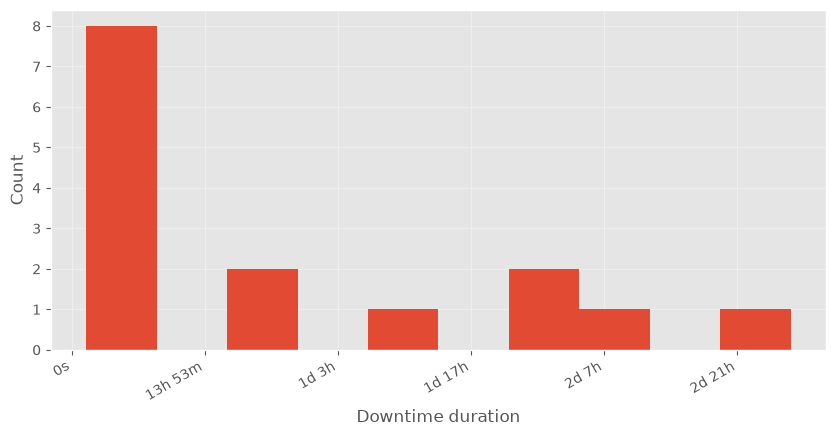

In [207]:


event_df = to_events(df["Available Capacity for Production (kW)"] == 2050.0, min_duration=pd.Timedelta("1.5hour"))
event_df["duration"] = event_df["end"] - event_df["start"]
def human_duration(seconds, _pos=None):
    seconds = int(seconds)
    if seconds <= 0:
        return "0s"
    days, rem = divmod(seconds, 86400)
    hours, rem = divmod(rem, 3600)
    minutes, secs = divmod(rem, 60)
    parts = []
    if days:    parts.append(f"{days}d")
    if hours:   parts.append(f"{hours}h")
    if minutes and not days:   parts.append(f"{minutes}m")
    if secs and not (days or hours or minutes): parts.append(f"{secs}s")
    return " ".join(parts)

downtime_duration_seconds = event_df[~event_df["is_operational"]]["duration"].dt.total_seconds()

fig, ax = plt.subplots(figsize=(10, 5))
downtime_duration_seconds.hist(bins=10, ax=ax)
ax.xaxis.set_major_formatter(FuncFormatter(human_duration))
fig.autofmt_xdate(rotation=30)  # optional: rotate labels for readability
ax.set_xlabel("Downtime duration")
ax.set_ylabel("Count");

In [208]:
# Poison distribution.
event_count = sum(~event_df["is_operational"])
interval = df.index.max() - df.index.min()
interval, event_count

(Timedelta('156 days 09:00:00'), 15)

In [217]:
# Chance of maintenance event per 10 minutes
tenMinuteCounts = interval/pd.Timedelta("10min")
print(f'{event_count}/{tenMinuteCounts:,.0f}={event_count/(tenMinuteCounts)}')

15/22,518=0.0006661337596589396


In [218]:
durationParam = stats.powerlaw.fit(downtime_duration_seconds.values)

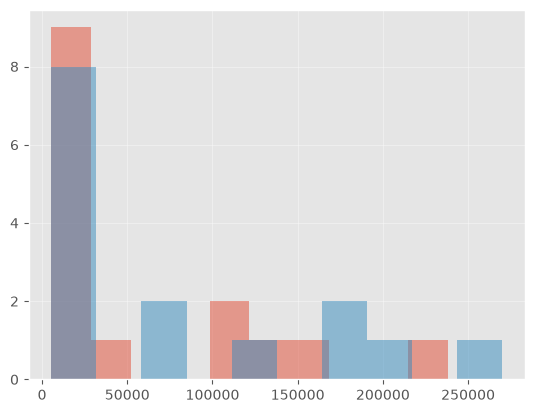

In [219]:
fix, ax = plt.subplots()
pd.Series(stats.powerlaw.rvs(*durationParam, size=len(downtime_duration_seconds))).hist(ax=ax, alpha=0.5)
pd.Series(downtime_duration_seconds).hist(alpha=0.5, ax=ax);

In [224]:
for _ in range(10):
    sim_event_count = np.sum(np.random.poisson(lam=15/22518, size=int(tenMinuteCounts)))
    print(f"Simulated events: {sim_event_count}. Actual events: {event_count}")

Simulated events: 19. Actual events: 15
Simulated events: 15. Actual events: 15
Simulated events: 16. Actual events: 15
Simulated events: 17. Actual events: 15
Simulated events: 19. Actual events: 15
Simulated events: 11. Actual events: 15
Simulated events: 21. Actual events: 15
Simulated events: 12. Actual events: 15
Simulated events: 19. Actual events: 15
Simulated events: 14. Actual events: 15


## Putting it all together.

Simulating it all from last wind speed.

In [232]:
wind_speed_0 = 7.0
sim_length = int(pd.Timedelta("1day")/pd.Timedelta("10min"))

In [233]:
sim_data = {}
for i in range(sim_length):
    ...